In [21]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
from spk_feat_cluster_comp_analysis  import *

In [22]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

#### Compiling the master dataset

We load all per-cell cluster pickle files — one per (cell, spike feature) pair — and concatenate them into a single master DataFrame. Each row is one pairwise cluster comparison (e.g., Low vs. High for `peak_amp` in c1), carrying both recording metadata (patch type, cell type, cortical depth, dark neuron flag) and clustering quality metrics (nRMSE, cos_sim, num_clusters, temporal_rho). Everything downstream depends on this table.

In [23]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [24]:
df_master

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
0,c1,Juxta,IC,PC,843.9,False,False,peak_amp,3,Low-High,0.097334,0.990675,-0.836876,1.362049e-294,1.0
1,c1,Juxta,IC,PC,843.9,False,False,peak_sharpness,3,Low-High,0.089531,0.994335,-0.696692,2.509393e-163,1.0
2,c1,Juxta,IC,PC,843.9,False,False,exp_lambda,3,Low-High,0.057151,0.991093,-0.513388,2.884357e-76,1.0
3,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-Mid,0.042822,0.998956,0.349626,1.720911e-33,1.0
4,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-High,0.039851,0.999172,0.349626,1.720911e-33,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-Mid,0.098067,0.906951,0.438847,1.952396e-289,1.0
124,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-High,0.057792,0.970615,0.438847,1.952396e-289,1.0
125,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Mid-High,0.043976,0.980540,0.438847,1.952396e-289,1.0
126,c46,Juxta,VC,PC,1039.7,False,True,exp_lambda,2,Low-High,0.008711,0.999816,-0.045723,3.193497e-04,1.0


In [25]:
#sort by cell id
# Create a numeric column for sorting (c1, c2, c10, etc.)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)

# Sort by the numeric ID, then by feature name
df_master = df_master.sort_values(by=['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])



#### Dataset overview

A figure-quality summary table of the full master DataFrame — all cells, all spike features, all cluster pairs. Useful for sanity-checking cell counts per feature, confirming metadata looks right, and getting a fast read on which cells have the cleanest waveform separations before diving into statistics.

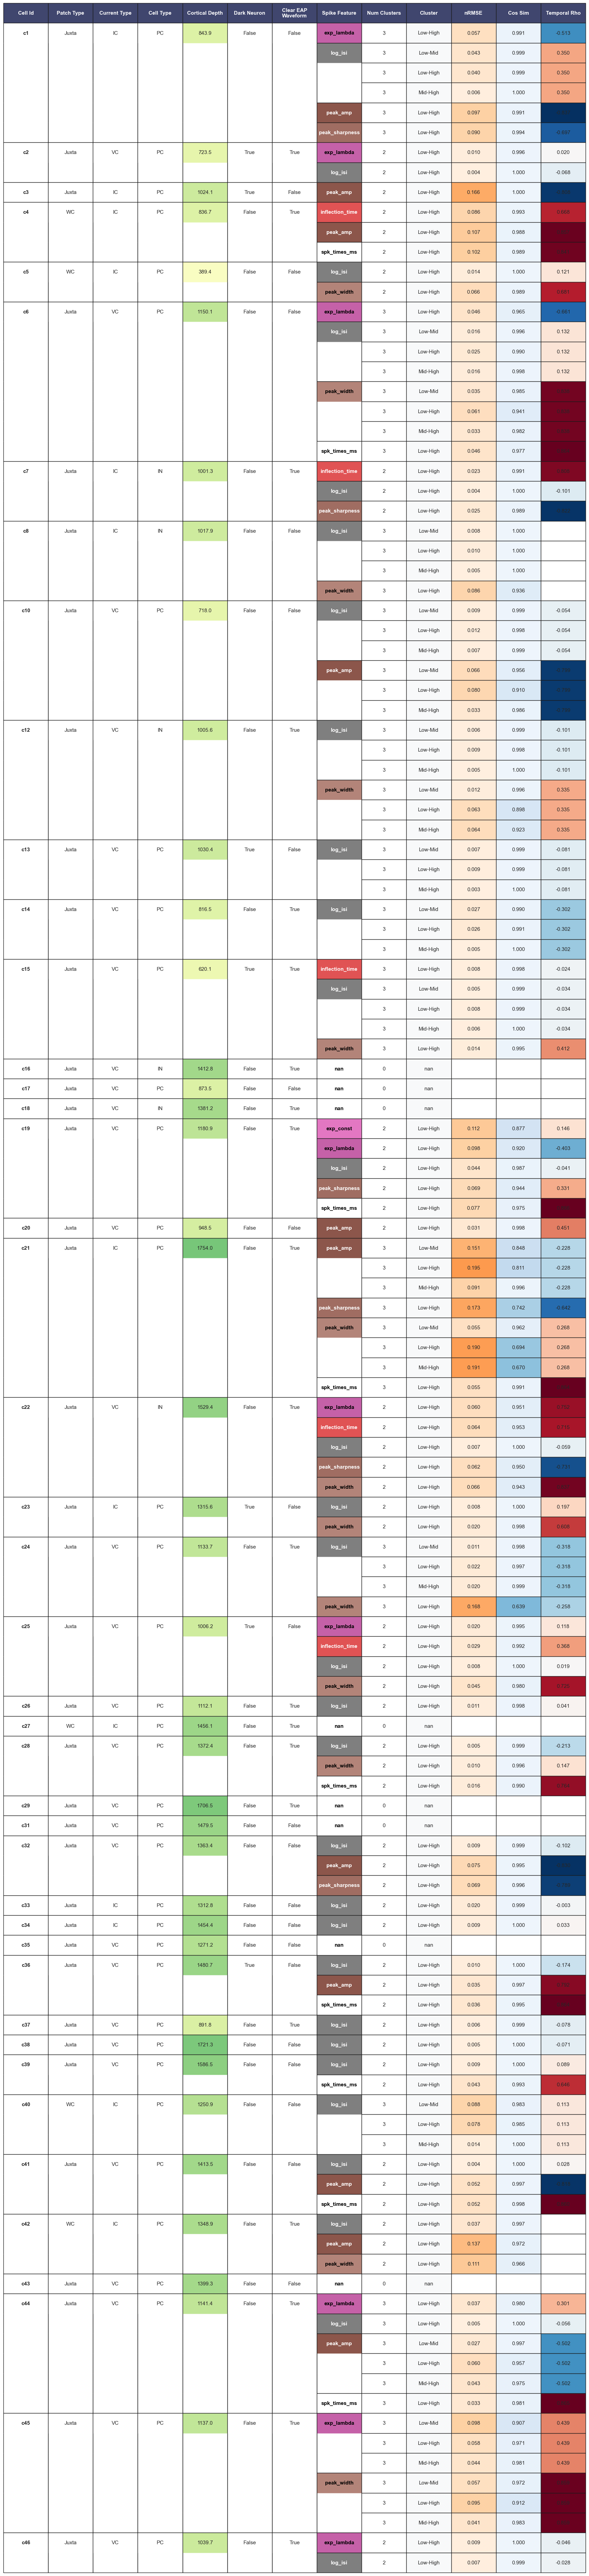

In [26]:

gen_table_fig(df_master)


### Are clustering results driven by biology or recording conditions?

Before interpreting spike waveform clusters as a biological signal, we need to rule out the possibility that clustering quality — or even *which* features cluster — is an artifact of how we recorded. The next three sections cross clustering metrics against recording metadata to test for confounds.

#### A. Does recording metadata predict cluster quality?

Spearman correlations between each metadata variable and the clustering quality metrics: nRMSE (larger = clusters have more different mean waveforms), cos_sim (lower = more different waveform shapes), and num_clusters. A significant association means clustering quality is tied to the recording condition — a potential confound we need to account for before making biological claims.

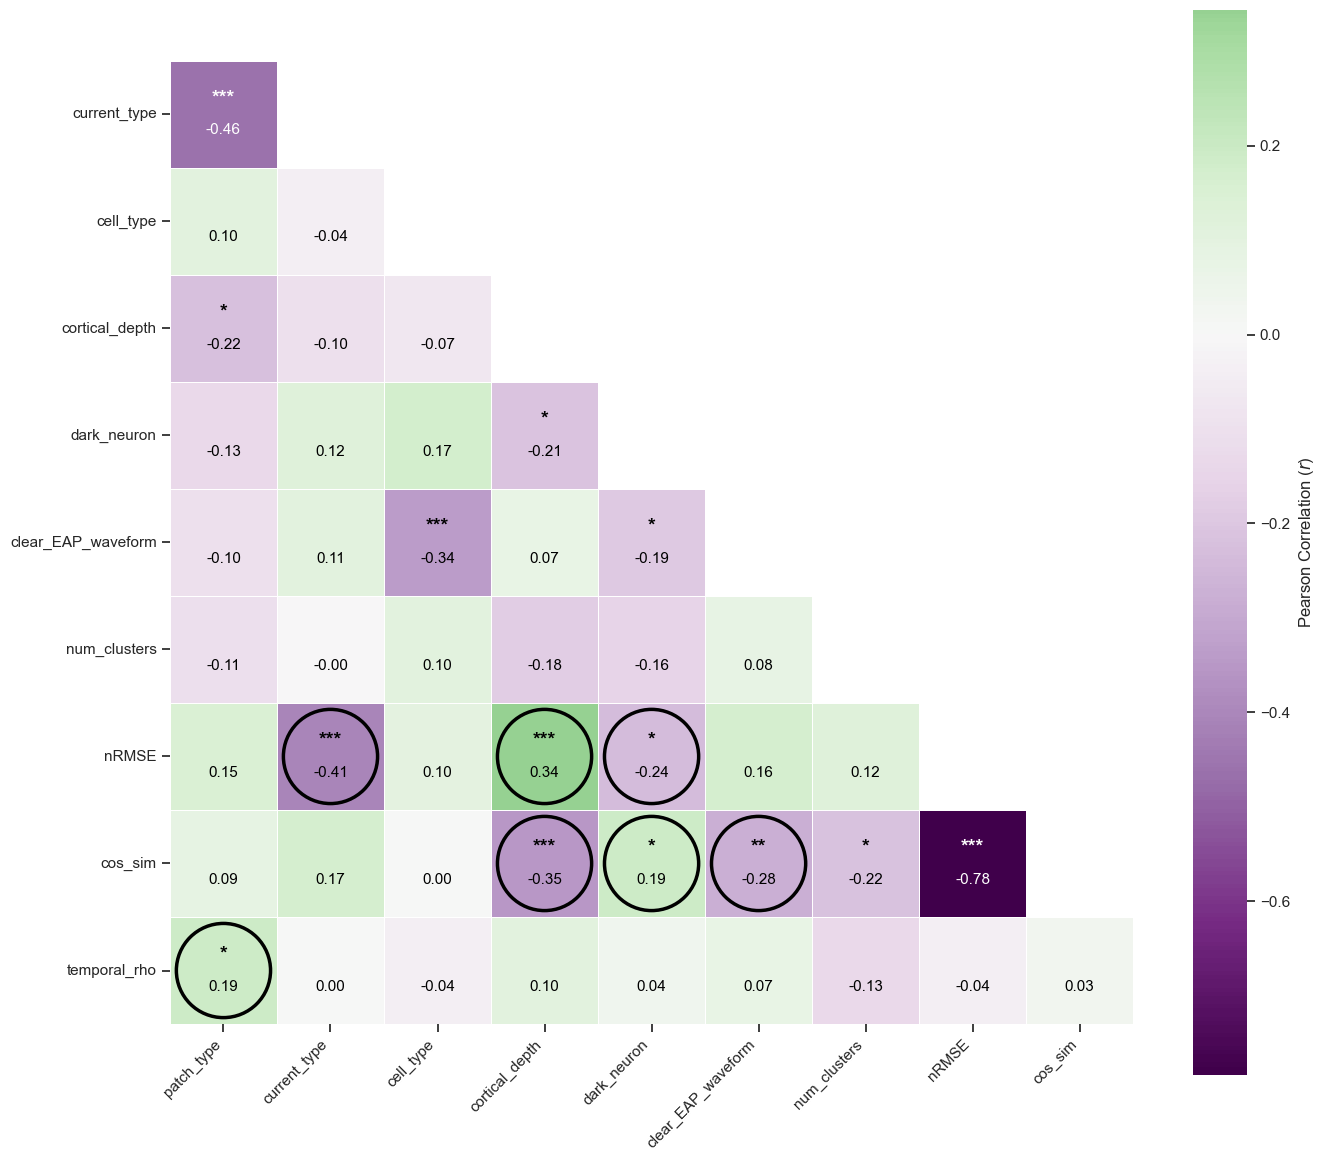

,Metadata,Feature,Pearson $r$,p-value,Significance
0,current_type,nRMSE,-0.407,7.58e-06,***
1,cortical_depth,cos_sim,-0.352,1.29e-04,***
2,cortical_depth,nRMSE,0.344,1.91e-04,***
3,clear_EAP_waveform,cos_sim,-0.279,2.81e-03,**
4,dark_neuron,nRMSE,-0.236,1.19e-02,*
5,patch_type,temporal_rho,0.193,4.06e-02,*
6,dark_neuron,cos_sim,0.190,4.35e-02,*


In [27]:
sig_meta_clust_feats = analyze_cross_correlations(df_master)
sig_meta_clust_feats

#### Visualizing the significant metadata–cluster pairs

Scatter plots for every pair that came up significant above. We're looking for monotonic trends vs. non-linear patterns, and flagging any combinations that could plausibly confound the biology (e.g., if nRMSE is higher in whole-cell recordings purely because of waveform broadening from the patch).

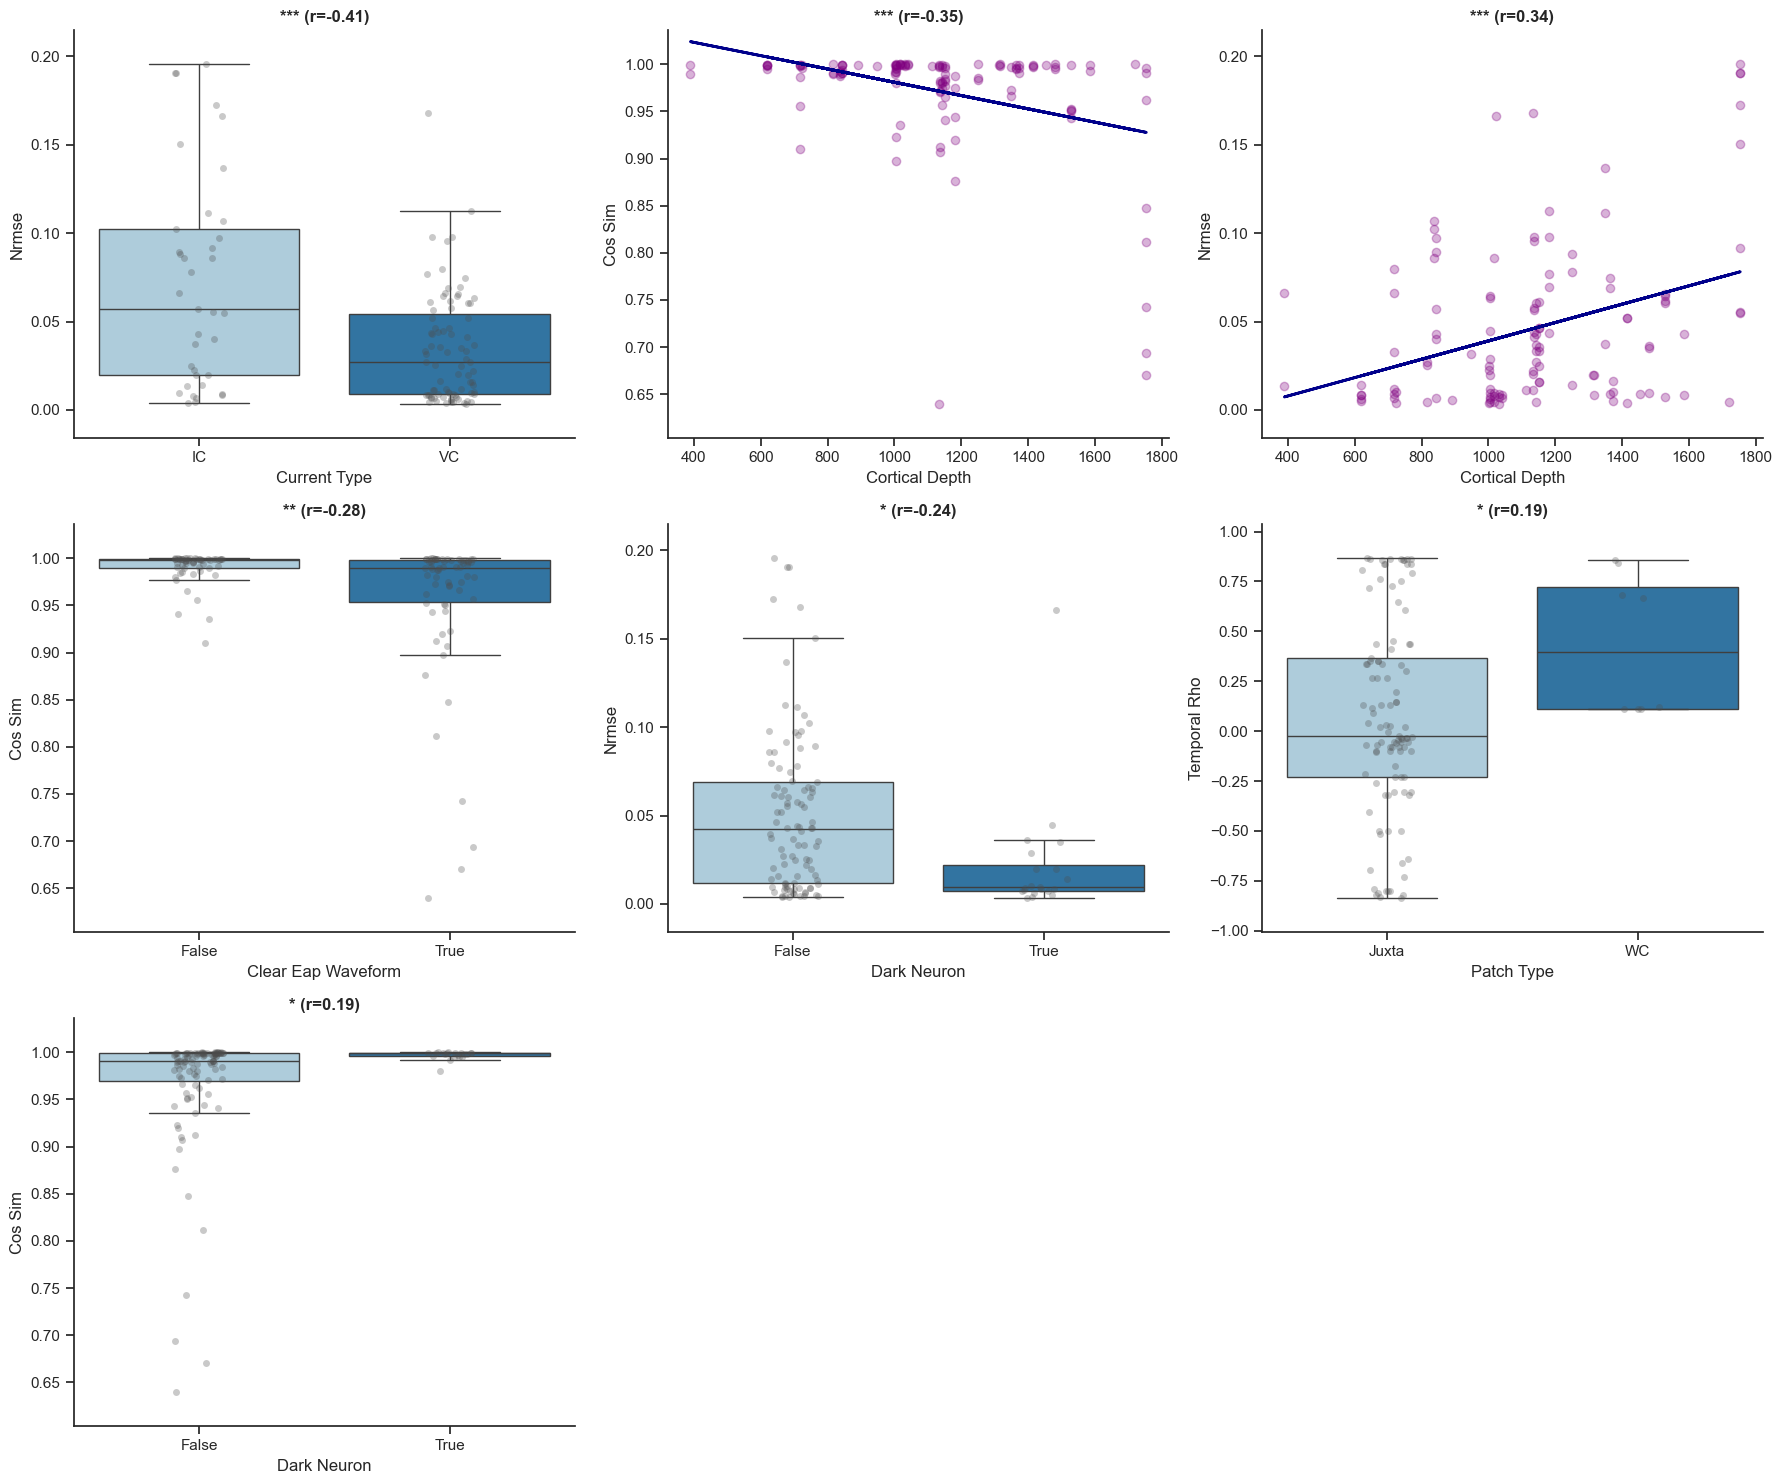

In [28]:
plot_sig_feat_pairs(df_master, sig_meta_clust_feats)



#### B. Which spike features show waveform clustering, and how reliable is it?

Not all spike features cluster equally well or as often. Here we ask: across the full population of cells, which features most commonly produce significant spike clusters, and when they do, how well-separated are those clusters in waveform space?

##### Feature prevalence and cluster quality per spike feature

Aggregated across all cells: how many cells yield a significant cluster for each spike feature, plus mean nRMSE, cos_sim, and temporal_rho. High prevalence + high nRMSE + low cos_sim = a feature that reliably produces well-separated, shape-distinct clusters across the population — the features worth prioritizing for LFP coupling analyses.

In [29]:
#Aggregate cluster metrics and prevalence by spike feature
spk_feat_prevalence = quantify_spk_feature_prevalence(df_master)


In [30]:
spk_feat_prevalence

,spike_feature,n_cells_with_feature,prevalence_pct,num_clusters,cos_sim,nRMSE,temporal_rho
3,log_isi,30,69.767442,2.620000,0.997801,0.015414,-0.029438
6,peak_width,13,30.232558,2.714286,0.921870,0.070711,0.529017
4,peak_amp,11,25.581395,2.588235,0.963162,0.085143,-0.361274
1,exp_lambda,9,20.930233,2.545455,0.968775,0.048846,0.080409
7,spk_times_ms,9,20.930233,2.333333,0.987679,0.051211,0.825800
5,peak_sharpness,6,13.953488,2.333333,0.935959,0.081216,-0.558334
2,inflection_time,5,11.627907,2.200000,0.985302,0.042013,0.507107
0,exp_const,1,2.325581,2.000000,0.876527,0.112284,0.145825


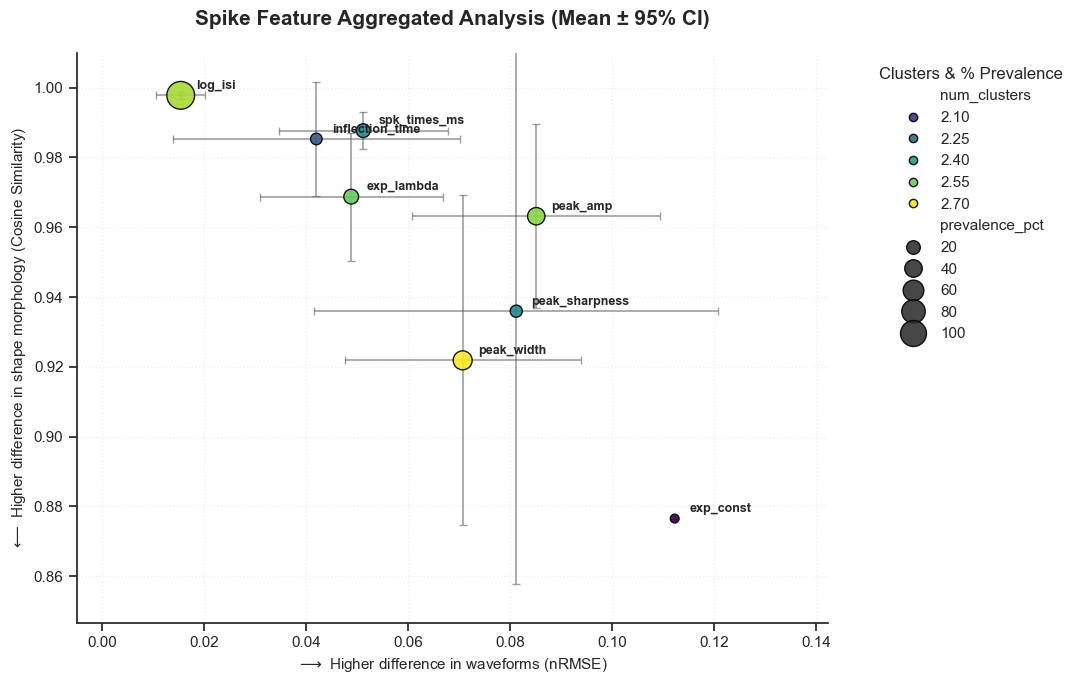

In [31]:
plot_aggregated_spike_feat(df_master)


##### Does metadata predict which spike features cluster?

Chi-square tests (categorical metadata × spike feature) and Spearman correlations (cortical depth × spike feature presence) check whether the features that cluster are skewed toward particular recording conditions. If `peak_width` only clusters in one cell type, that's a biology statement — but if it only clusters in whole-cell recordings, that's a confound.

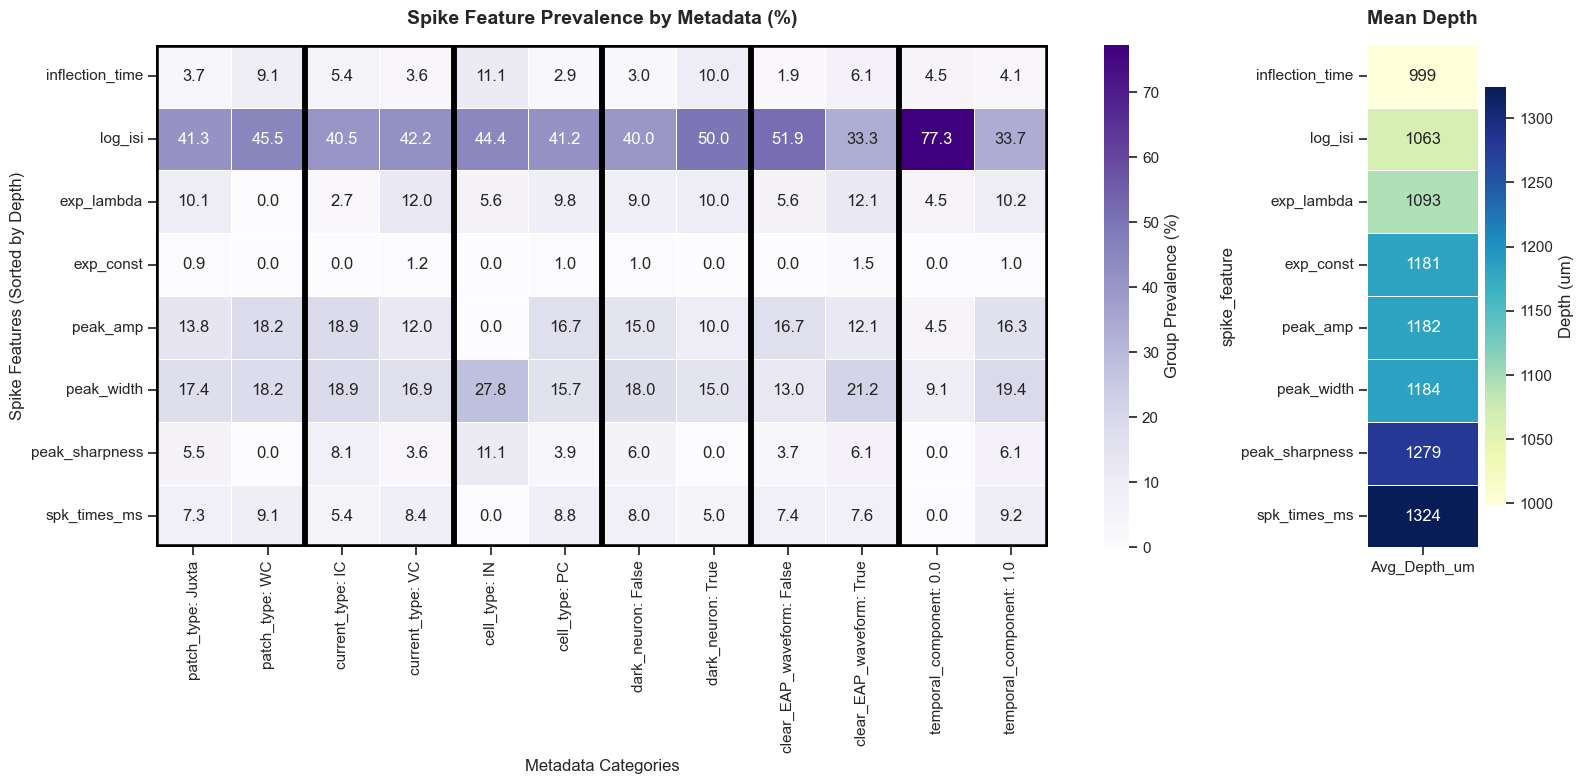

In [32]:
plot_meta_spk_feature_dependency(df_master)

In [33]:

_ = stat_test_metadata_dependency(df_master)

----------------------------------------
METADATA DEPENDENCY ANALYSIS (Chi-Square)
----------------------------------------
patch_type           | p = 9.076e-01 (ns)
current_type         | p = 6.163e-01 (ns)
cell_type            | p = 1.662e-01 (ns)
dark_neuron          | p = 7.377e-01 (ns)
clear_EAP_waveform   | p = 3.468e-01 (ns)
temporal_rho         | p = 2.933e-11 (***)
temporal_p           | p = 3.318e-07 (***)
temporal_component   | p = 3.264e-02 (*)
----------------------------------------


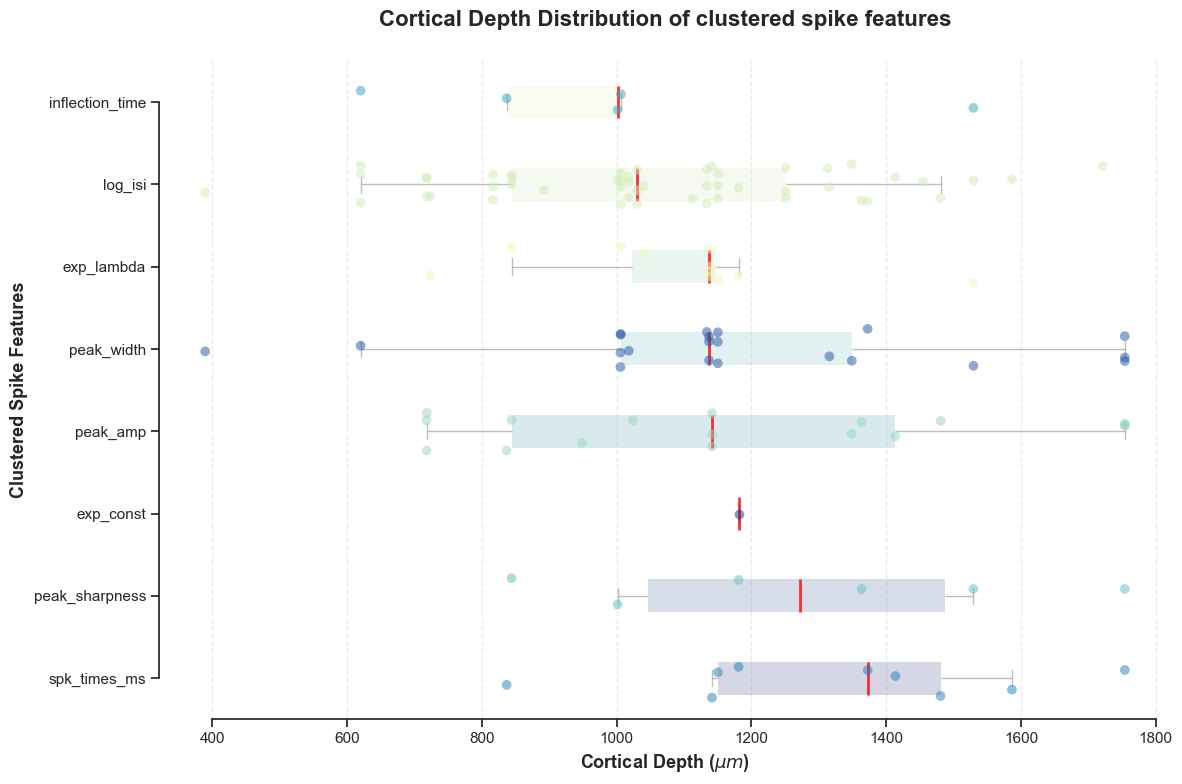

In [34]:
plot_feature_depth_distribution(df_master)

In [35]:
_ =stat_test_depth_stratification(df_master)

----------------------------------------
DEPTH STRATIFICATION ANALYSIS
----------------------------------------
Kruskal-Wallis H-stat: 10.583
p-value: 1.579e-01

No significant depth stratification found.
----------------------------------------


#### C. Which cell × spike feature pairs show the largest waveform differences across clusters?

The top N entries by nRMSE (mean waveform displacement across clusters) and 1 − cos_sim (waveform shape dissimilarity). These are the recordings where cluster identity matters most for spike shape — the strongest candidates for biologically meaningful waveform variability, and the natural starting points for single-cell deep dives.

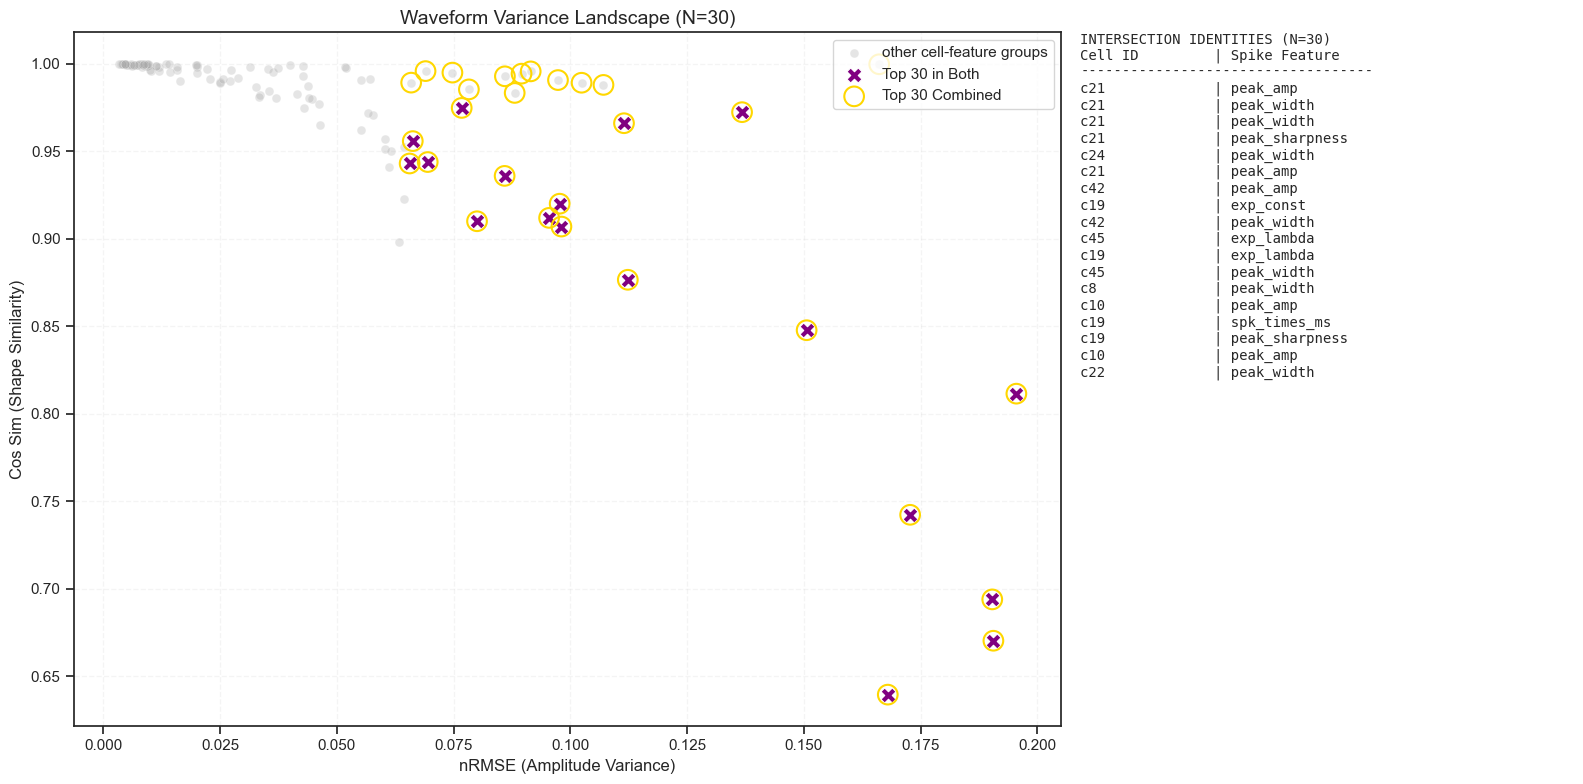

In [36]:
top_var_df = analyze_waveform_variance(df_master, N=30)

In [37]:
top_var_df 

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
62,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-High,0.195481,0.811435,-0.227997,1.471553e-115,1.0
66,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Mid-High,0.190562,0.670219,0.267964,1.651480e-160,1.0
65,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Low-High,0.190318,0.693848,0.267964,1.651480e-160,1.0
67,c21,Juxta,IC,PC,1754.0,False,True,peak_sharpness,3,Low-High,0.172733,0.742203,-0.642336,0.000000e+00,1.0
76,c24,Juxta,VC,PC,1133.7,False,True,peak_width,3,Low-High,0.167947,0.639413,-0.257935,1.408160e-60,1.0
61,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-Mid,0.150572,0.847696,-0.227997,1.471553e-115,1.0
110,c42,WC,IC,PC,1348.9,False,True,peak_amp,2,Low-High,0.136746,0.972326,NaN,NaN,0.0
57,c19,Juxta,VC,PC,1180.9,False,True,exp_const,2,Low-High,0.112284,0.876527,0.145825,4.277999e-24,1.0
111,c42,WC,IC,PC,1348.9,False,True,peak_width,2,Low-High,0.111467,0.966011,NaN,NaN,0.0
123,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-Mid,0.098067,0.906951,0.438847,1.952396e-289,1.0


#### D. Do spike clusters drift systematically over recording time?

If a cell's cluster identity (Low / Mid / High) correlates with spike time, the neuron's firing is changing over the course of the recording — possibly due to electrode drift, pharmacology, or genuine slow state changes in the network. We measure this via Spearman correlation (`temporal_rho`) between spike time and cluster label, and flag cells where drift is statistically significant.

A significant `temporal_rho` means cluster identity shifts monotonically over the recording (positive ρ = spikes move toward one cluster as time progresses; negative = the reverse). `temporal_component = 1` if that drift is statistically significant (p < 0.05); 0 otherwise. Temporal drift doesn't automatically invalidate clustering, but it means LFP × spike cluster relationships should be interpreted carefully — a pre-spike LFP effect in a drifting cell could partly reflect slow recording-level changes rather than fast network modulation.

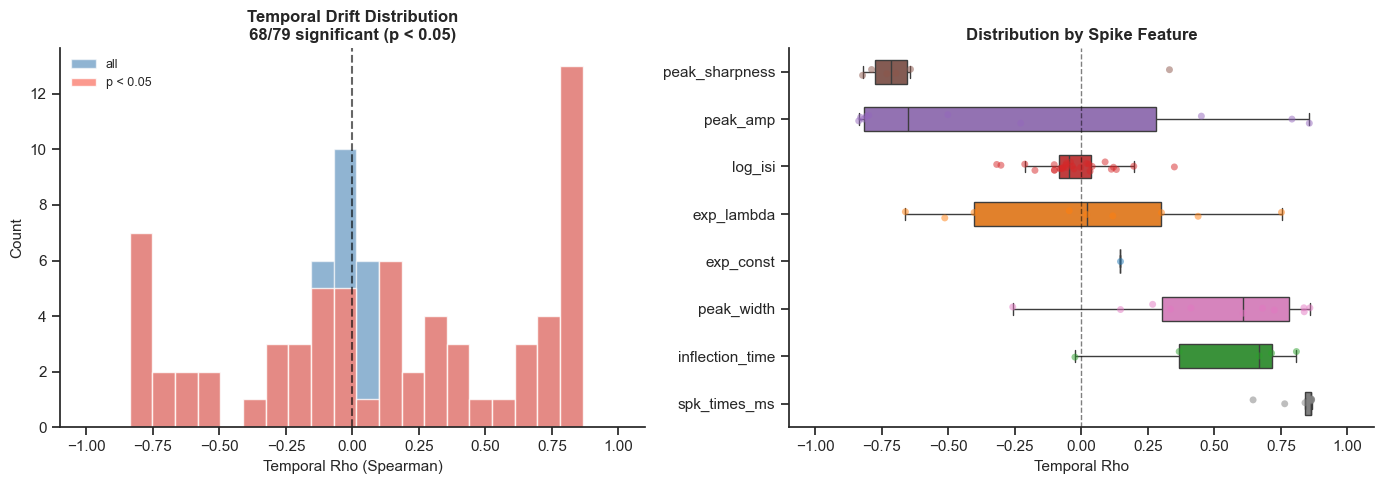


Temporal drift summary (p < 0.05):
  Significant: 68 / 79 cell-feature groups (86.1%)
  Mean |rho|: 0.422

Significant groups:
cell_id   spike_feature  temporal_rho temporal_p
     c1        peak_amp        -0.837    <0.0001
    c32        peak_amp        -0.830    <0.0001
     c7  peak_sharpness        -0.822    <0.0001
    c41        peak_amp        -0.818    <0.0001
     c3        peak_amp        -0.808    <0.0001
    c10        peak_amp        -0.799    <0.0001
    c32  peak_sharpness        -0.789    <0.0001
    c22  peak_sharpness        -0.731    <0.0001
     c1  peak_sharpness        -0.697    <0.0001
     c6      exp_lambda        -0.661    <0.0001
    c21  peak_sharpness        -0.642    <0.0001
     c1      exp_lambda        -0.513    <0.0001
    c44        peak_amp        -0.502    <0.0001
    c19      exp_lambda        -0.403    <0.0001
    c24         log_isi        -0.318    <0.0001
    c14         log_isi        -0.302    <0.0001
    c24      peak_width        -0.258  

In [38]:
df_temporal = plot_temporal_structure(df_master)

#### E. Do recording conditions predict temporal drift?

We test whether `temporal_rho` is systematically larger in certain cell types, patch types, or depth ranges. If whole-cell recordings drift more than juxtacellular, that implicates electrode stability over biology. Knowing what drives drift helps us decide when to treat `temporal_component = 1` cells as outliers vs. as genuine slow-modulation biology.

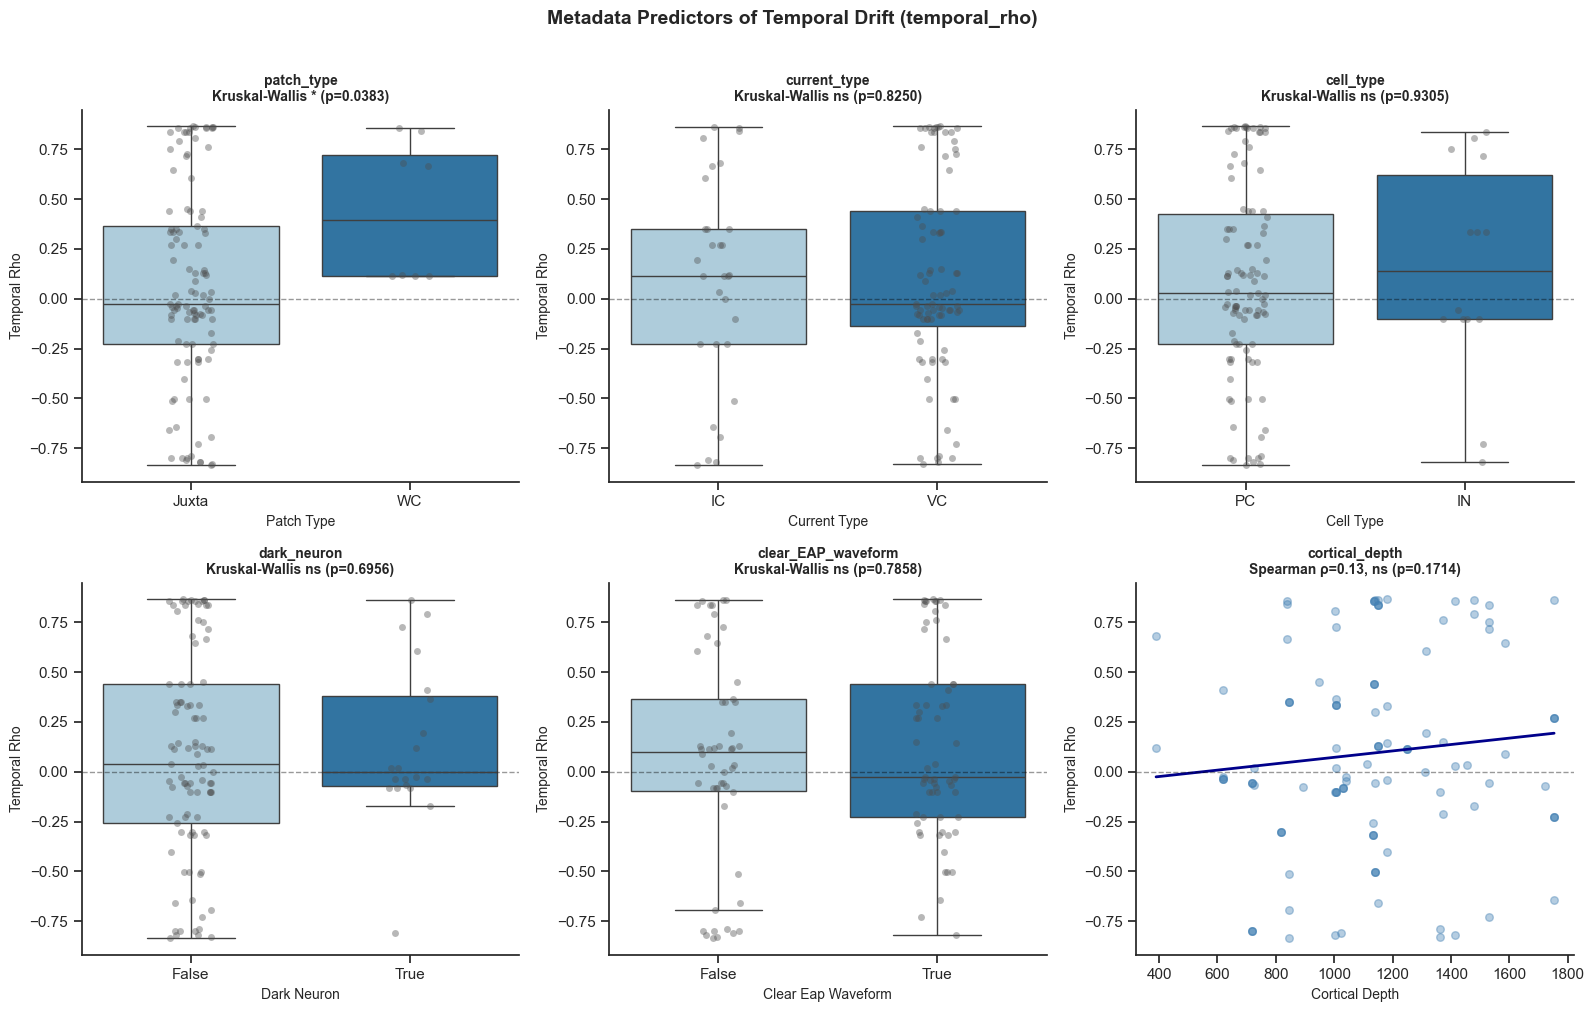


Metadata → temporal_rho test results:
          variable           test  statistic        p sig
        patch_type Kruskal-Wallis      4.290 0.038336   *
    cortical_depth       Spearman      0.130 0.171420  ns
       dark_neuron Kruskal-Wallis      0.153 0.695618  ns
clear_EAP_waveform Kruskal-Wallis      0.074 0.785827  ns
      current_type Kruskal-Wallis      0.049 0.825018  ns
         cell_type Kruskal-Wallis      0.008 0.930544  ns


,variable,test,statistic,p,sig
0,patch_type,Kruskal-Wallis,4.290,0.038336,*
1,cortical_depth,Spearman,0.130,0.171420,ns
2,dark_neuron,Kruskal-Wallis,0.153,0.695618,ns
3,clear_EAP_waveform,Kruskal-Wallis,0.074,0.785827,ns
4,current_type,Kruskal-Wallis,0.049,0.825018,ns
5,cell_type,Kruskal-Wallis,0.008,0.930544,ns


In [39]:
temporal_meta_results = analyze_temporal_metadata_dependency(df_master)
temporal_meta_results

#### F. Does temporal drift correlate with stronger waveform cluster separation?

If cells with more temporal drift also show higher nRMSE or lower cos_sim, it raises the possibility that some of the apparent waveform variability is a slow drift artifact rather than fast modulation by network state. We test this directly — if the correlation is strong, drifting cells should be down-weighted in any population-level effect size claims.

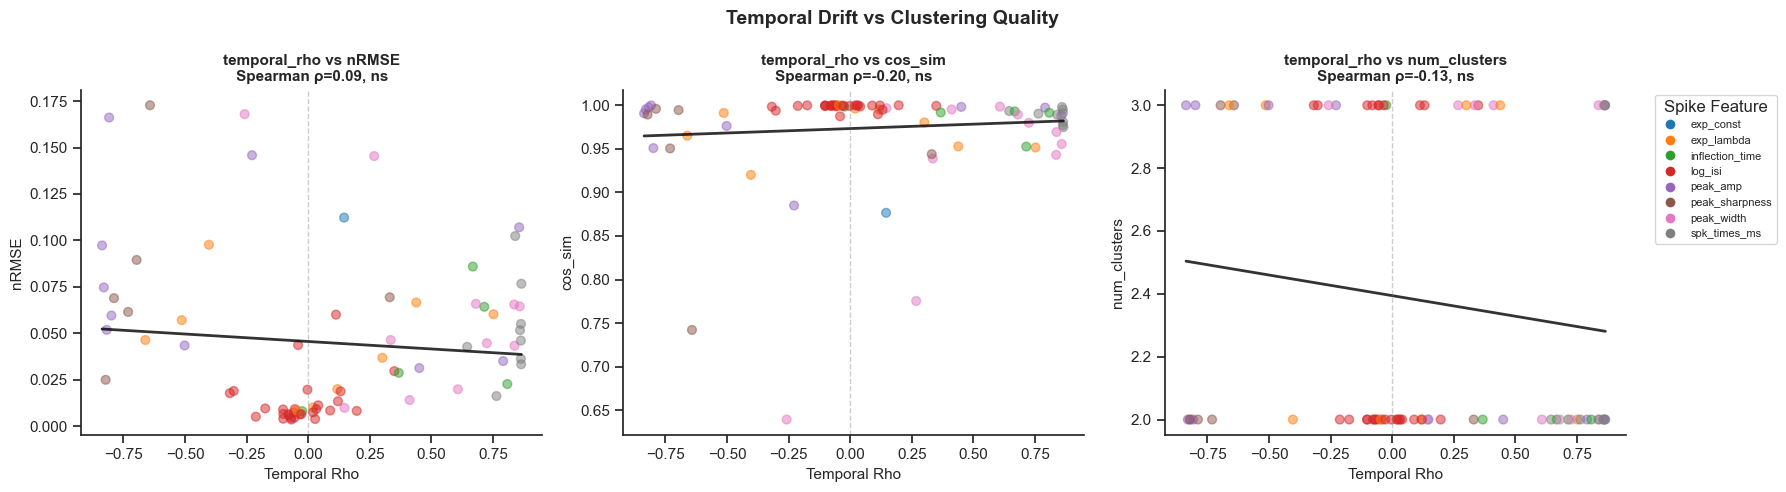

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:960: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_feat.set_xticklabels(ax_feat.get_xticklabels(), rotation=30, ha='right')


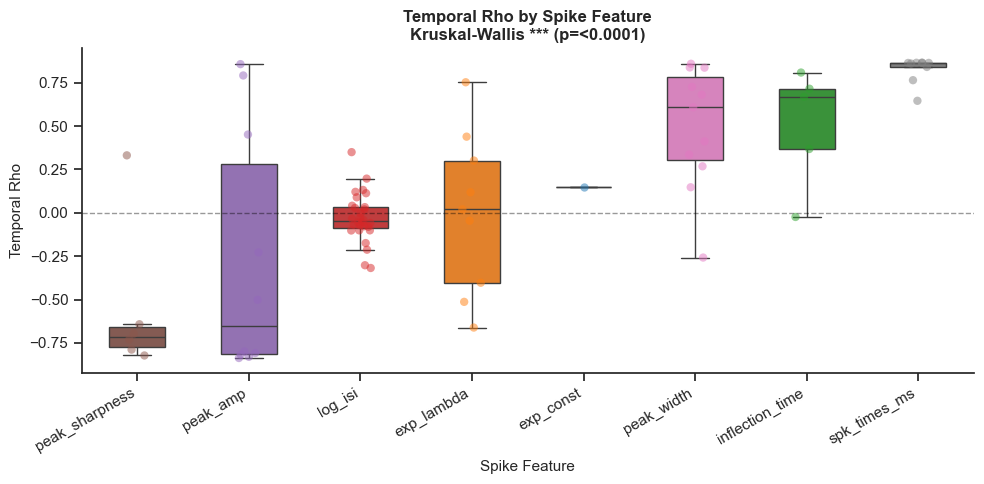

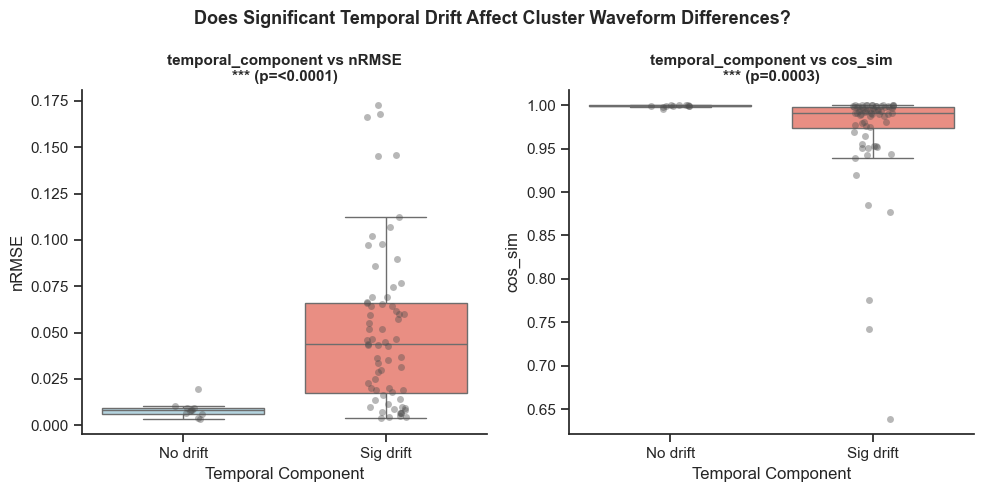


temporal_rho vs clustering metrics (Spearman):
      metric  spearman_rho        p sig
       nRMSE         0.092 0.420185  ns
     cos_sim        -0.200 0.077083  ns
num_clusters        -0.130 0.252061  ns


,metric,spearman_rho,p,sig
0,nRMSE,0.092,0.420185,ns
1,cos_sim,-0.200,0.077083,ns
2,num_clusters,-0.130,0.252061,ns


In [40]:
temporal_clust_results = analyze_temporal_clustering_relationship(df_master)
temporal_clust_results